**AUTH dan Set up**

In [1]:
import pandas as pd
import numpy as np
import os
import re

# 1. Konfigurasi Path Lokal (Tidak perlu Google Colab lagi)
INPUT_FILE = "/Users/komings/Downloads/orcas/data/raw/DATASET BANKING [IDX].xlsx"
OUTPUT_PATH = "/Users/komings/Downloads/orcas/data/processed/"
if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

# 2. Master List 32 Emiten
TICKERS = [
    "AGRS", "ARTO", "BABP", "BACA", "BBCA", "BBKP", "BBNI", "BBRI",
    "BBTN", "BDMN", "BINA", "BJBR", "BJTM", "BKSW", "BMAS", "BMRI",
    "BNBA", "BNGA", "BNII", "BNLI", "BSIM", "BTPN", "BVIC", "DNAR",
    "INPC", "MAYA", "MCOR", "MEGA", "NISP", "NOBU", "PNBN", "SDRA"
]

# 3. Mapping 40 Metrik
METRICS_STRUCTURE = {
    "CASHFLOW STATEMENT": [
        "Arus Kas Dari Aktivitas Operasi", "Arus Kas Dari Aktivitas Investasi",
        "Arus Kas Dari Aktivitas Pendanaan", "Kenaikan (Penurunan) Bersih Kas dan Setara Kas",
        "Kas Dan Setara Kas Awal Periode", "Kas Dan Setara Kas Akhir Periode",
        "Operating Cash Flow", "Capital expenditure", "Free cash flow", "Free cash flow per share"
    ],
    "BALANCE SHEET": [
        "Total Aset", "Kas Dan Setara Kas", "Giro Pada Bank Indonesia",
        "Penempatan Pada Bank Indonesia", "Pinjaman Yang Diberikan", "Aset Tetap",
        "Simpanan Nasabah", "Pinjaman yang Diterima", "Total Liabilitas",
        "Total Ekuitas", "Price to Book Value (PBV)", "Book Value Per Share (BVPS)",
        "Tangible Book Value Per Share", "Asset Turnover"
    ],
    "INCOME STATEMENT": [
        "Total Pendapatan", "Total Beban Pokok Penjualan", "Laba Kotor",
        "Beban Usaha", "Laba Usaha", "Pendapatan/Beban Lain-lain",
        "Laba Sebelum Pajak", "Beban Pajak Penghasilan", "Laba Bersih Tahun Berjalan",
        "Jumlah Laba Komprehensif", "Saham Beredar (Share Outstanding)",
        "Earnings per Share (EPS)", "Price to Earnings Ratio (PER)",
        "Price to Sales (P/S)", "Return on Assets (ROA)", "Return on Equity (ROE)"
    ]
}

In [ ]:
all_data = []
for t in TICKERS:
    print(f"Memproses {t}...")
    all_data.extend(process_emiten(t))

df_master = pd.DataFrame(all_data)

for year in range(2015, 2025):
    yr_str = str(year)
    df_yr = df_master[df_master['Year'] == yr_str]

    # Pivot supaya Ticker menjadi lajur
    df_pivot = df_yr.pivot_table(index=['Section', 'Metric'], columns='Ticker', values='Value', sort=False).reset_index()

    # Pastikan semua 40 metrik wujud (isi NaN jika tiada)
    full_metrics = []
    for sec, mets in METRICS_STRUCTURE.items():
        for m in mets:
            full_metrics.append({'Section': sec, 'Metric': m})
    df_template = pd.DataFrame(full_metrics)

    df_final = pd.merge(df_template, df_pivot, on=['Section', 'Metric'], how='left')
    df_final.insert(0, 'Year', yr_str)

    df_final.to_csv(os.path.join(OUTPUT_PATH, f"{yr_str}.csv"), index=False)
    print(f"Berhasil Export: {yr_str}.csv")

Pada bagian ini, loop `for year in range(2015, 2025):` bertanggung jawab untuk memproses data per tahun. Di dalam loop tersebut, baris kode `df_final.to_csv(os.path.join(OUTPUT_PATH, f"{yr_str}.csv"), index=False)` adalah yang menyimpan DataFrame yang telah diproses untuk setiap tahun ke dalam file CSV terpisah.

File-file ini disimpan di lokasi yang didefinisikan oleh `OUTPUT_PATH`, yaitu `/content/drive/MyDrive/ORCAS/data_clean/`. Anda dapat menemukan file-file seperti `2015.csv`, `2016.csv`, dan seterusnya hingga `2024.csv` di folder tersebut di Google Drive Anda.

**Cleaning**

In [2]:
def clean_val(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().replace(',', '')
    if not s or s in ["", "-", "n/a", "null", "nan"]: return np.nan
    
    is_neg = True if '(' in s and ')' in s else False
    for cl in ['(', ')', ' B', ' T', '%', 'B', 'T']: 
        s = s.replace(cl, '')
        
    try:
        res = float(s)
        res = -res if is_neg else res
        return res / 100.0 if '%' in str(v) else res
    except: 
        return np.nan

def process_all_local():
    xls = pd.ExcelFile(INPUT_FILE)
    results = []
    
    # Process each sheet (ticker)
    for ticker in xls.sheet_names:
        if ticker not in TICKERS: continue
        
        df = pd.read_excel(xls, sheet_name=ticker)
        # Verify years available
        available_years = [y for y in range(2015, 2025) if y in df.columns]
        
        for _, row in df.iterrows():
            metric_cell = str(row.get('Financial Metrics', '')).strip()
            
            # Map section & metric
            found_sec, found_met = None, None
            for sec, mets in METRICS_STRUCTURE.items():
                for m in mets:
                    if m.lower() == metric_cell.lower():
                        found_sec, found_met = sec, m
                        break
                if found_met: break
                
            if not found_met: continue
            
            for yr in available_years:
                val = row[yr]
                final_val = clean_val(val)
                # Apply % division if needed
                if '%' in str(val) and not pd.isna(final_val):
                    final_val = final_val / 100.0
                    
                results.append({
                    'Year': str(yr), 
                    'Section': found_sec, 
                    'Metric': found_met, 
                    'Ticker': ticker, 
                    'Value': final_val
                })
                
    return results

**Ekstraksi dan Transformasi**

In [3]:
print("Memproses file Excel lokal berskala besar untuk 32 emiten...")
all_data = process_all_local()
df_master = pd.DataFrame(all_data)

for year in range(2015, 2025):
    yr_str = str(year)
    df_yr = df_master[df_master['Year'] == yr_str]
    if df_yr.empty: continue

    # Pivot supaya Ticker menjadi lajur
    df_pivot = df_yr.pivot_table(index=['Section', 'Metric'], columns='Ticker', values='Value', sort=False).reset_index()

    # Pastikan semua 40 metrik wujud (isi NaN jika tiada)
    full_metrics = []
    for sec, mets in METRICS_STRUCTURE.items():
        for m in mets:
            full_metrics.append({'Section': sec, 'Metric': m})
    df_template = pd.DataFrame(full_metrics)

    df_final = pd.merge(df_template, df_pivot, on=['Section', 'Metric'], how='left')
    df_final.insert(0, 'Year', yr_str)

    # Pastikan semua 32 ticker ada walau nilainya NaN
    for t in TICKERS:
        if t not in df_final.columns:
            df_final[t] = np.nan

    # Rapikan susunan kolom
    cols = ['Year', 'Section', 'Metric'] + sorted(TICKERS)
    df_final = df_final[cols]

    out_file = os.path.join(OUTPUT_PATH, f"{yr_str}.csv")
    df_final.to_csv(out_file, index=False)
    print(f"Berhasil Export (bersih & final): {yr_str}.csv")

print("Selesai! 10 file CSV bersih berhasil dibuat di folder data/processed.")

Memproses file Excel lokal berskala besar untuk 32 emiten...


FileNotFoundError: [Errno 2] No such file or directory: '/Users/komings/Downloads/orcas/data/raw/DATASET BANKING [IDX].xlsx'

**Integrasi Data (Merging)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Konfigurasi awal visualisasi
sns.set_theme(style="whitegrid")
PATH_CLEAN = "/content/drive/MyDrive/ORCAS/data_clean/"
years = [str(y) for y in range(2015, 2025)]
all_data = []

# Load dan gabungkan data
for yr in years:
    file = os.path.join(PATH_CLEAN, f"{yr}.csv")
    if os.path.exists(file):
        df_yr = pd.read_csv(file)
        all_data.append(df_yr)

df_master = pd.concat(all_data, ignore_index=True)

# Transformasi data ke format Long (Tidy Data) untuk mempermudah plotting
tickers = [c for c in df_master.columns if c not in ['Year', 'Section', 'Metric']]
df_eda = df_master.melt(id_vars=['Year', 'Section', 'Metric'],
                        value_vars=tickers,
                        var_name='Ticker',
                        value_name='Value')

print(f"Total data terintegrasi: {len(df_eda)} baris.")

Total data terintegrasi: 12800 baris.


**Statistik Deskriptif**

In [ ]:
# Menampilkan profil statistik untuk metrik terpilih di setiap Section
sections = ['CASHFLOW STATEMENT', 'BALANCE SHEET', 'INCOME STATEMENT']
key_metrics = ['Return on Assets (ROA)', 'Total Aset', 'Free cash flow', 'Total Ekuitas']

summary = df_eda[df_eda['Metric'].isin(key_metrics)].groupby(['Section', 'Metric'])['Value'].describe()

print("Statistik Deskriptif Metrik Utama:")
display(summary.round(4))

Statistik Deskriptif Metrik Utama:


count         mean          std  \
Section            Metric                                                    
BALANCE SHEET      Total Aset              320.0  232401.6593  419975.8492   
                   Total Ekuitas           320.0   34763.5344   62870.5389   
CASHFLOW STATEMENT Free cash flow          320.0    4657.9531   20316.8322   
INCOME STATEMENT   Return on Assets (ROA)  320.0       0.0069       0.0169   

                                                  min         25%         50%  \
Section            Metric                                                       
BALANCE SHEET      Total Aset               -232.9500  16939.2500  78327.0000   
                   Total Ekuitas             107.0000   3145.2500   9045.5000   
CASHFLOW STATEMENT Free cash flow         -88102.0000  -1158.0000    258.5000   
INCOME STATEMENT   Return on Assets (ROA)     -0.0923      0.0031      0.0083   

                                                   75%           max  
Section            Metric                                             
BALANCE SHEET      Total Aset              204921.5000  2.427223e+06  
                   Total Ekuitas            33274.0000  3.231890e+05  
CASHFLOW STATEMENT Free cash flow            4027.5000  1.263680e+05  
INCOME STATEMENT   Return on Assets (ROA)       0.0142  3.780000e-02

**Analisis Tren Historis (Time Series)**

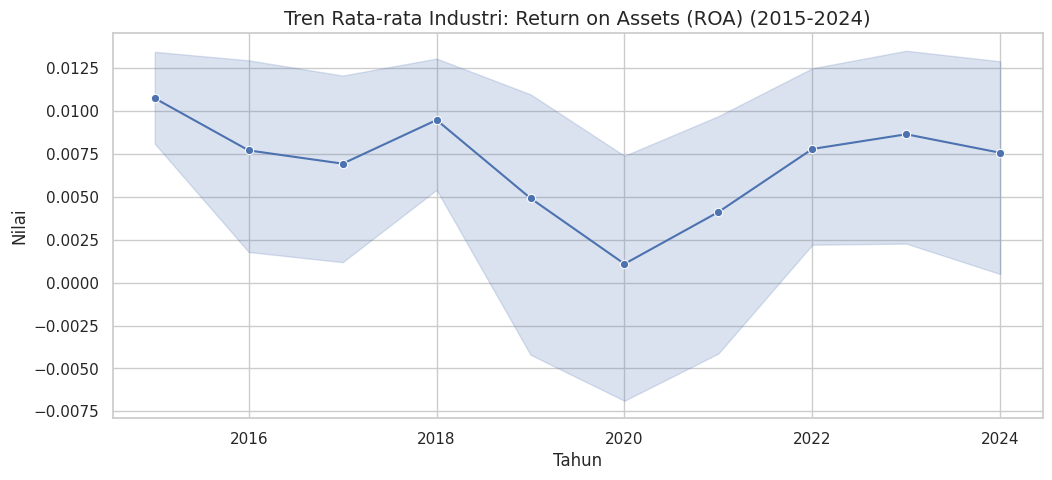

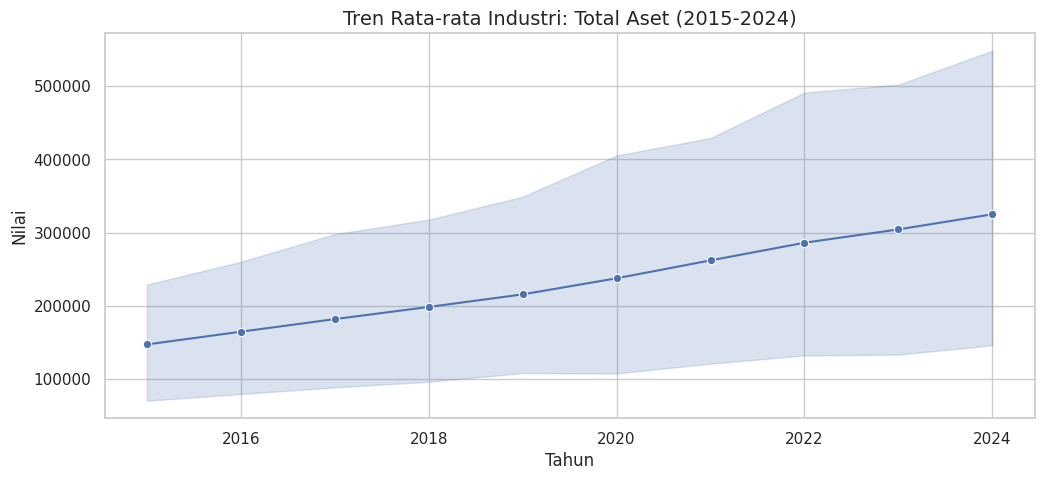

In [ ]:
# Plot Tren Rata-rata ROA (Income Statement) dan Total Aset (Balance Sheet)
metrics_to_plot = ['Return on Assets (ROA)', 'Total Aset']

for m in metrics_to_plot:
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df_eda[df_eda['Metric'] == m], x='Year', y='Value', marker='o', estimator='mean')
    plt.title(f'Tren Rata-rata Industri: {m} (2015-2024)', fontsize=14)
    plt.ylabel('Nilai')
    plt.xlabel('Tahun')
    plt.show()

**Analisis Distribusi dan Outlier**

/tmp/ipython-input-2678136191.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda['Metric'] == 'Return on Equity (ROE)'], x='Year', y='Value', palette='viridis')


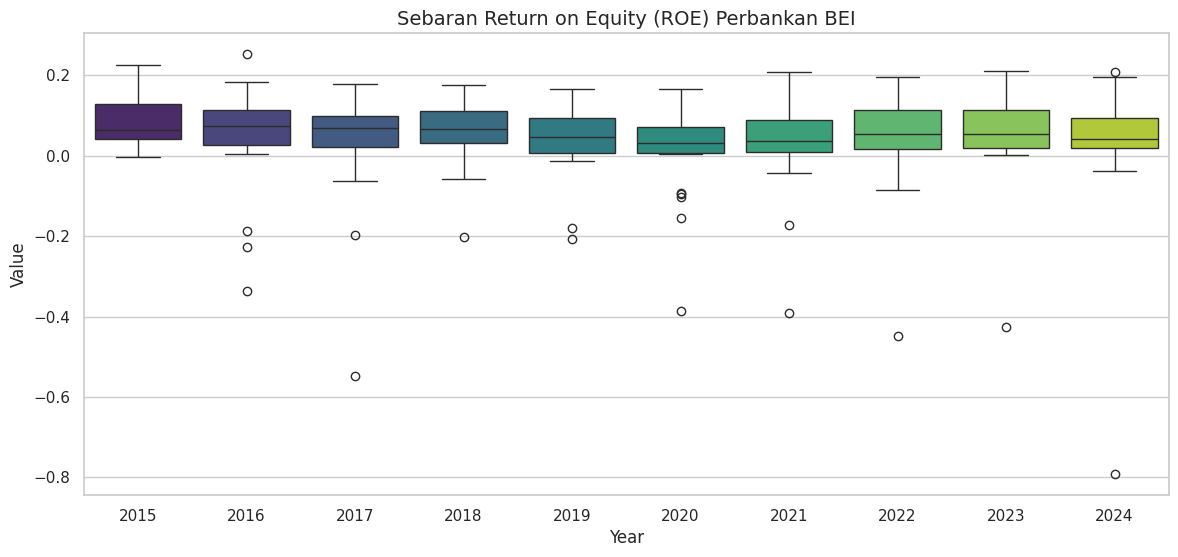

In [ ]:
# Boxplot untuk melihat variasi ROE antar bank per tahun
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_eda[df_eda['Metric'] == 'Return on Equity (ROE)'], x='Year', y='Value', palette='viridis')
plt.title('Sebaran Return on Equity (ROE) Perbankan BEI', fontsize=14)
plt.show()

**Korelasi Metrik Financial Section**

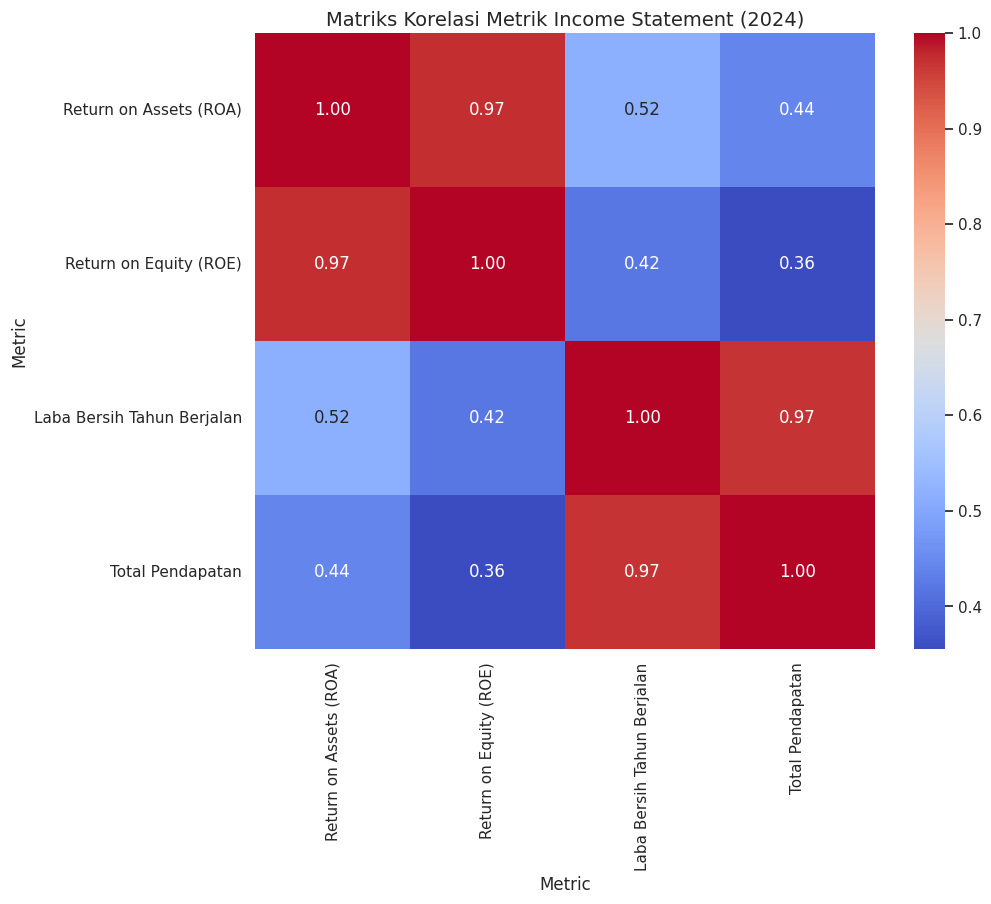

In [ ]:
# Korelasi untuk metrics di INCOME STATEMENT (Tahun 2024)
df_2024 = df_eda[(df_eda['Year'] == 2024) & (df_eda['Section'] == 'INCOME STATEMENT')]
df_pivot_corr = df_2024.pivot(index='Ticker', columns='Metric', values='Value')

# Pilih beberapa metrik populer untuk heatmap
subset_metrics = ['Return on Assets (ROA)', 'Return on Equity (ROE)', 'Laba Bersih Tahun Berjalan', 'Total Pendapatan']
corr_matrix = df_pivot_corr[subset_metrics].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Metrik Income Statement (2024)', fontsize=14)
plt.show()

## **PROTOTIPE WSM**

**Penentuan Tipe Kriteria (Benefit vs Cost)**

In [ ]:
# 1. Definisi Tipe Kriteria (Contoh untuk 5 metrik kunci)
# Benefit: Nilai tinggi = Bagus (ROA, ROE, Laba, Aset)
# Cost: Nilai tinggi = Buruk (Beban Pokok, Beban Usaha)
CRITERIA_TYPES = {
    'Return on Assets (ROA)': 'benefit',
    'Return on Equity (ROE)': 'benefit',
    'Total Aset': 'benefit',
    'Total Beban Pokok Penjualan': 'cost',
    'Beban Usaha': 'cost'
}

# 2. Definisi Bobot Default (Total harus 1.0 atau 100%)
# Di sistem web Anda, ini akan bersifat fleksibel/input user
DEFAULT_WEIGHTS = {
    'Return on Assets (ROA)': 0.30,
    'Return on Equity (ROE)': 0.20,
    'Total Aset': 0.20,
    'Total Beban Pokok Penjualan': 0.15,
    'Beban Usaha': 0.15
}

print("Kriteria dan Bobot WSM telah didefinisikan.")

Kriteria dan Bobot WSM telah didefinisikan.


**Logika Perhitungan WSM (Normalisasi & Scoring)**

In [ ]:
def calculate_wsm(df_input, year):
    # Filter data berdasarkan tahun
    df_yr = df_input[df_input['Year'] == int(year)].copy()

    # Ambil metrik yang masuk dalam kriteria pembobotan saja
    metrics_to_calc = list(DEFAULT_WEIGHTS.keys())
    df_calc = df_yr[df_yr['Metric'].isin(metrics_to_calc)]

    # Pivot agar Ticker menjadi baris (Alternatif WSM)
    df_pivoted = df_calc.pivot(index='Ticker', columns='Metric', values='Value')

    # Proses Normalisasi Min-Max
    df_norm = df_pivoted.copy()
    for col in df_pivoted.columns:
        col_min = df_pivoted[col].min()
        col_max = df_pivoted[col].max()

        if CRITERIA_TYPES[col] == 'benefit':
            # Persamaan 3.1: (x - min) / (max - min)
            df_norm[col] = (df_pivoted[col] - col_min) / (col_max - col_min)
        else:
            # Persamaan 3.2: (max - x) / (max - min)
            df_norm[col] = (col_max - df_pivoted[col]) / (col_max - col_min)

    # Perhitungan Skor Akhir (Persamaan 3.3)
    # Skor = Penjumlahan (Bobot * Nilai Ternormalisasi)
    df_norm['Total_Score'] = 0
    for col, weight in DEFAULT_WEIGHTS.items():
        df_norm['Total_Score'] += df_norm[col] * weight

    return df_norm.sort_values(by='Total_Score', ascending=False)

print("Fungsi Perhitungan WSM Skripsi-Ready telah siap.")

Fungsi Perhitungan WSM Skripsi-Ready telah siap.


**Simulasi Perankingan Akhir**

In [ ]:
# Eksekusi WSM untuk data tahun 2024
ranking_2024 = calculate_wsm(df_eda, 2024)

print("HASIL PERANKINGAN KESEHATAN BANK (TAHUN 2024):")
display(ranking_2024[['Total_Score']].head(10)) # Menampilkan Top 10

# Export hasil ke CSV untuk dokumentasi tambahan Bab 4
ranking_2024.to_csv(os.path.join(PATH_CLEAN, "WSM_Ranking_2024.csv"))
print("\nRanking berhasil disimpan ke Google Drive.")

HASIL PERANKINGAN KESEHATAN BANK (TAHUN 2024):


Metric,Total_Score
Ticker,
BBRI,0.940732
BMRI,0.865914
BBCA,0.721210
BBNI,0.637857
BNGA,0.501201
BBTN,0.493233
NISP,0.481849
BDMN,0.468355
BTPN,0.466175



Ranking berhasil disimpan ke Google Drive.
